Using: cuda
Epoch [1/50] Train Loss:2.3122 | Val Loss:1.9849 | Train Acc:15.50% | Val Acc:23.91%
Epoch [2/50] Train Loss:1.8557 | Val Loss:1.7592 | Train Acc:27.46% | Val Acc:29.70%
Epoch [3/50] Train Loss:1.7090 | Val Loss:1.5944 | Train Acc:32.80% | Val Acc:39.02%
Epoch [4/50] Train Loss:1.6304 | Val Loss:1.5126 | Train Acc:36.70% | Val Acc:41.79%
Epoch [5/50] Train Loss:1.5247 | Val Loss:1.5078 | Train Acc:41.36% | Val Acc:42.46%
Epoch [6/50] Train Loss:1.5064 | Val Loss:1.8765 | Train Acc:42.56% | Val Acc:36.06%
Epoch [7/50] Train Loss:1.4870 | Val Loss:1.4273 | Train Acc:44.04% | Val Acc:45.71%
Epoch [8/50] Train Loss:1.4080 | Val Loss:1.5047 | Train Acc:46.88% | Val Acc:44.75%
Epoch [9/50] Train Loss:1.3772 | Val Loss:1.3458 | Train Acc:48.44% | Val Acc:49.39%
Epoch [10/50] Train Loss:1.3462 | Val Loss:1.3478 | Train Acc:49.08% | Val Acc:49.85%
Epoch [11/50] Train Loss:1.2952 | Val Loss:1.3091 | Train Acc:51.34% | Val Acc:50.74%
Epoch [12/50] Train Loss:1.2532 | Val Loss:1.2855 |

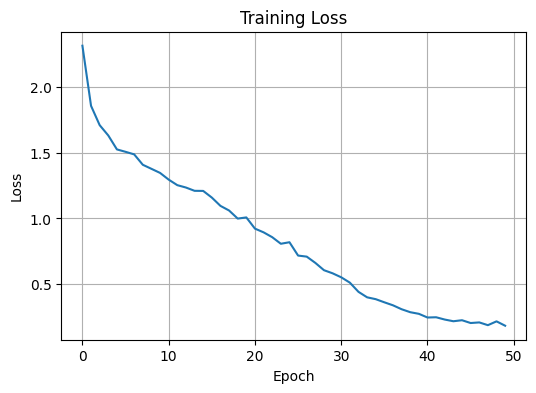

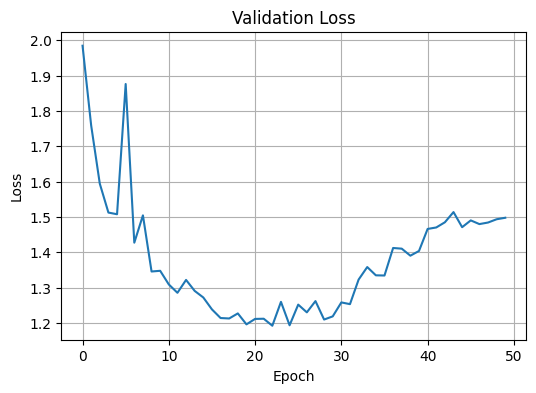

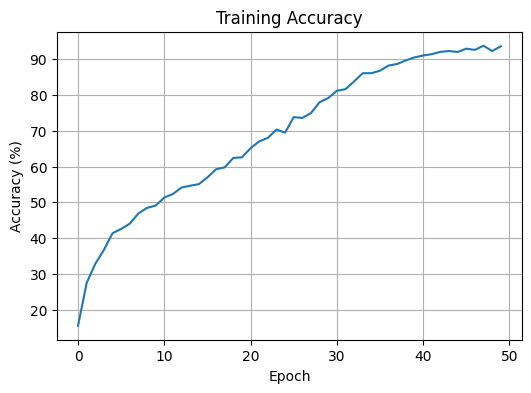

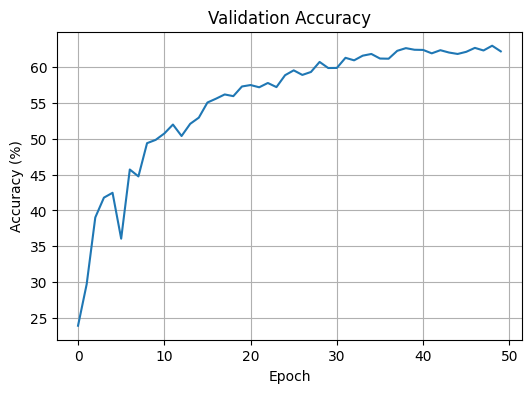

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import models

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:",device)

num_epochs=50
batch_size=64
learning_rate=0.001

transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset=torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset=torchvision.datasets.STL10(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

model=models.alexnet(weights=None)
model.classifier[6]=nn.Linear(4096,10)
model.to(device)

def custom_init(model):
    for module in model.modules():
        if isinstance(module,nn.Conv2d):
            nn.init.kaiming_normal_(
                module.weight,
                mode='fan_out',
                nonlinearity='relu'
            )
        elif isinstance(module,nn.Linear):
            nn.init.orthogonal_(module.weight)

        if hasattr(module,'bias') and module.bias is not None:
            nn.init.constant_(module.bias,0)

custom_init(model)

criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=learning_rate
)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

train_loss_list=[]
val_loss_list=[]
train_acc_list=[]
val_acc_list=[]

for epoch in range(num_epochs):

    model.train()
    train_loss=0
    correct=0
    total=0

    for images,labels in train_loader:

        images,labels=images.to(device),labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        train_loss+=loss.item()

        _,predicted=torch.max(outputs,1)

        total+=labels.size(0)

        correct+=(predicted==labels).sum().item()

    train_loss/=len(train_loader)

    train_acc=100*correct/total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)


    model.eval()

    val_loss=0
    correct=0
    total=0

    with torch.no_grad():

        for images,labels in test_loader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            val_loss+=loss.item()

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)

            correct+=(predicted==labels).sum().item()

    val_loss/=len(test_loader)

    val_acc=100*correct/total

    val_loss_list.append(val_loss)

    val_acc_list.append(val_acc)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss:{train_loss:.4f} | "
        f"Val Loss:{val_loss:.4f} | "
        f"Train Acc:{train_acc:.2f}% | "
        f"Val Acc:{val_acc:.2f}%"
    )

print(f"\nFinal Test Accuracy: {val_acc_list[-1]:.2f}%")

plt.figure(figsize=(6,4))
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_loss_list)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc_list)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_acc_list)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()